# Dispersal

**Dr. Panagiotis Sakagiannis, Dr. Alexandros Marantis**

## About this notebook

The previous notebook watched larvae explore a dish. This one *measures* it, and checks the answer
against real animals.

**Dispersal** is the distance of a larva from where it started, as a function of time. It is the
natural summary of exploration : it does not care which direction an animal chose, only how
effectively it left the place it began. Measuring it requires two things that the `dish` experiment
does not give you - every animal released from the same point, and an arena large enough that they
do not hit the wall - and both are exactly what the stored `dispersion` experiment provides.

Then comes the part that makes this the most important notebook of the section. Larvaworld ships a
**recording of real larvae**, processed through the same pipeline as the simulation, so simulated
and real populations can be drawn on the same axes with no further work. That comparison is the
central validation figure of Sakagiannis et al. (2025).

**What you will be able to do afterwards**

- Run an experiment designed for a spatial measurement rather than for watching.
- Say what dispersal is and over which window it is meaningful.
- Put a simulated and a recorded population into the same figure.
- Judge, from the figures, where the model matches the animals and where it does not.

**Prerequisites** : [Free exploration](free_exploration.ipynb).

**Cost** : a few minutes for the simulation. The reference recording is already on disc.

**Switches in this notebook**

| switch | default | what it turns on |
|---|---|---|
| `RUN_SIMULATION` | `True` | the experiment itself, and therefore every figure below |
| `SAVE_VIDEO` | `False` | a second run that renders the arena to a video file |

## Setup

In [1]:
%matplotlib inline

import larvaworld
from larvaworld.lib import reg
from larvaworld.lib.sim.single_run import ExpRun

larvaworld.VERBOSE = 1

# Tutorial safety switches
RUN_SIMULATION = True  # the point of this notebook; a few minutes of compute
SAVE_VIDEO = False  # re-run with rendering and write a video file

EXPERIMENT = "dispersion"
N = 20  # larvae; the stored experiment's duration and timestep are left untouched

MEDIA_DIR = "./media/simulated_experiments"
plot_dir = f"{MEDIA_DIR}/{EXPERIMENT}"

Initializing larvaworld registry


Registry configured!


## Section 1 : The experiment

Two differences from `dish`, and both exist for the measurement. The arena is a 200 mm square rather
than a 100 mm dish, so the animals have room to disperse before they reach a wall. And the larva
group is placed with zero spread : every animal starts at the centre, so distance from the start is
the same quantity for all of them.

In [2]:
conf = reg.conf.Exp.getID(EXPERIMENT)
env = conf.env_params

print(f"Experiment : {EXPERIMENT}")
print(f"  duration : {conf.duration} min   timestep : {conf.dt} s")
print(
    f"  arena    : {env.arena.geometry}, {[round(x * 1000) for x in env.arena.dims]} mm"
)

sources = env.food_params.source_units
if sources:
    print("  odor sources :")
    for sid, s in sources.items():
        pos_mm = [round(v * 1000, 1) for v in s.pos]
        print(
            f"     {sid:5s} at {pos_mm} mm, odor {s.odor.id!r} "
            f"(intensity {s.odor.intensity}, spread {s.odor.spread:.3f})"
        )
    print(f"  odorscape : {env.odorscape.odorscape}")
else:
    print("  odor sources : none")

for gid, g in conf.larva_groups.items():
    dis = g.distribution
    print(
        f"  larva group {gid!r} : model {g.model if isinstance(g.model, str) else '(inline)'}, "
        f"N={dis.N} placed {dis.mode} around {[round(v * 1000) for v in dis.loc]} mm"
    )

Experiment : dispersion
  duration : 5.0 min   timestep : 0.1 s
  arena    : rectangular, [200, 200] mm
  odor sources : none
  larva group 'explorer' : model explorer, N=30 placed uniform around [0, 0] mm


The experiment's enrichment is what actually produces the measurement. `dsp_starts` and `dsp_stops`
ask for dispersal to be computed over the windows 0-40 s and 0-60 s, which is why those columns
exist in the dataset without anyone computing them afterwards.

In [3]:
enr = conf.enrichment
print("Metrics computed after the run :")
print(f"  processing   : {enr.proc_keys}")
print(f"  annotation   : {enr.anot_keys}")
print(f"  dispersal    : from {enr.dsp_starts} s to {enr.dsp_stops} s")
print(f"  tortuosity   : over {enr.tor_durs} s windows")

Metrics computed after the run :
  processing   : ['angular', 'spatial']
  annotation   : ['bout_detection', 'bout_distribution', 'interference']
  dispersal    : from [0.0] s to [40.0, 60.0] s
  tortuosity   : over [5, 10, 20] s windows


## Section 2 : Running it

In [4]:
r = ExpRun(experiment=EXPERIMENT, N=N)

print(
    f"{EXPERIMENT!r} : {r.p.duration} min at dt={r.p.dt} s, "
    f"{r.p.larva_groups[r.p.larva_groups.keylist[0]].distribution.N} larvae"
)

'dispersion' : 5.0 min at dt=0.1 s, 20 larvae


In [5]:
d_sim = None
if RUN_SIMULATION:
    r.simulate()
    d_sim = r.datasets[0]
    print(f"{d_sim.id} : {d_sim.config.N} larvae, stored at {d_sim.dir}")
else:
    print("Set RUN_SIMULATION = True to run the experiment.")

--- Simulation dispersion_32 initialized!--- 
--- Simulation dispersion_32 : Generating agent groups!--- 



Run time: 0:00:58.484742
Simulation finished
--- Simulation dispersion_32 completed in 59 seconds!--- 
--- Enriching dataset explorer ---
Vector orientations are already computed. If you want to recompute them, set recompute to True


Angular analysis complete.
Spatial analysis complete.
Dispersal analysis complete.
Dispersal analysis complete.


Tortuosity analysis complete.


Tortuosity analysis complete.


...

Completed bout detection.
Completed bout detection.


Fitted pooled epoch durations.
Completed Lturn bout distribution analysis.
Completed Rturn bout distribution analysis.
Completed Lturn_dur bout distribution analysis.
Completed Rturn_dur bout distribution analysis.
Failed to complete Lturn_amp bout distribution analysis.
Completed Rturn_amp bout distribution analysis.
Completed turn_dur bout distribution analysis.
Failed to complete turn_amp bout distribution analysis.
Failed to complete turn_vel_max bout distribution analysis.
Completed vel_minima bout distribution analysis.
Completed vel_maxima bout distribution analysis.
Completed stride bout distribution analysis.
Completed exec bout distribution analysis.
Completed run_count bout distribution analysis.
Completed stride_Dor bout distribution analysis.
Completed stride_dur bout distribution analysis.
Completed stride_dst bout distribution analysis.
Completed stride_idx bout distribution analysis.
Completed run_dur bout distribution analysis.
Completed run_dst bout distribution analy

Computed average curves during stridecycle for diverse parameters.
Completed stridecycle interference analysis.
--- Dataset explorer enriched ---
--------------------------------


***** Dataset explorer stored.-----
Simulation dispersion_32 stored in directory C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/dispersion/dispersion_32


explorer : 20 larvae, stored at C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/dispersion/dispersion_32/data/explorer


In [6]:
if SAVE_VIDEO:
    r_vid = ExpRun(
        experiment=EXPERIMENT,
        N=N,
        screen_kws={
            "vis_mode": "video",
            "show_display": False,
            "save_video": True,
            "media_dir": MEDIA_DIR,
            "video_file": "dispersion",
            "visible_trails": True,
        },
    )
    r_vid.simulate()
    print(f"Video written to {MEDIA_DIR}/dispersion.mp4")
else:
    print("Set SAVE_VIDEO = True to render this experiment to a video file.")

Set SAVE_VIDEO = True to render this experiment to a video file.


## Section 3 : The analysis

Every stored experiment knows which figures belong to it. `ExpRun.analyze()` looks the experiment up,
runs the plots registered for that kind of assay, writes them next to the datasets, and returns them
grouped by topic in `r.figs`. Nothing has to be chosen by hand.

In [7]:
if RUN_SIMULATION:
    r.analyze()
    print("Figure groups produced :")
    for gname, group in r.figs.items():
        print(f"  {gname:12s} {list(group)}")
    print()
    print(f"All of them were also written to {r.plot_dir}")

Plot comparative_trajectories_default.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/dispersion/dispersion_32/plots/traj\comparative_trajectories_default.pdf


Plot aligned2origin.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/dispersion/dispersion_32/plots/traj\aligned2origin.pdf


Plot runsNpauses.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/dispersion/dispersion_32/plots/general\runsNpauses.pdf


Plot end_box_basic.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/dispersion/dispersion_32/plots/endpoint\end_box_basic.pdf


Plot end_box_basic.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/dispersion/dispersion_32/plots/endpoint\end_box_basic.pdf


...

Plot dsp_summary_(0, 40).pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/dispersion/dispersion_32/plots/dsp\dsp_summary_(0, 40).pdf


Plot stride_cycle_curves.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/dispersion/dispersion_32/plots/stride\stride_cycle_curves.pdf


Plot stride_cycle_curves_all_larvae.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/dispersion/dispersion_32/plots/stride\stride_cycle_curves_all_larvae.pdf


Plot annotated_strideplot.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/dispersion/dispersion_32/plots/track\annotated_strideplot.pdf


Plot annotated_turnplot.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/dispersion/dispersion_32/plots/track\annotated_turnplot.pdf
Figure groups produced :
  traj         ['trajectories', 'aligned2origin']
  general      ['epochs']
  endpoint     ['endpoint box', 'crawl pars']
  distro       ['distros', 'angular pars']
  dsp          ['dispersal', 'dispersal summary']
  stride       ['stride cycle']
  track        ['stride track', 'turn track']

All of them were also written to C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/dispersion/dispersion_32/plots


`r.figs` holds the figure objects themselves, so they can be shown here one group at a time.

In [8]:
def show(group):
    """Display every figure of one analysis group."""
    if not RUN_SIMULATION or group not in r.figs:
        return
    for name, fig in r.figs[group].items():
        print(name)
        display(fig)

### Dispersal

The measurement this experiment exists for : distance from the starting point against time, as the
group median with the spread across animals, and the same curve placed next to the trajectories that
produced it. The window is the first 40 seconds, for the reason given below.

dispersal


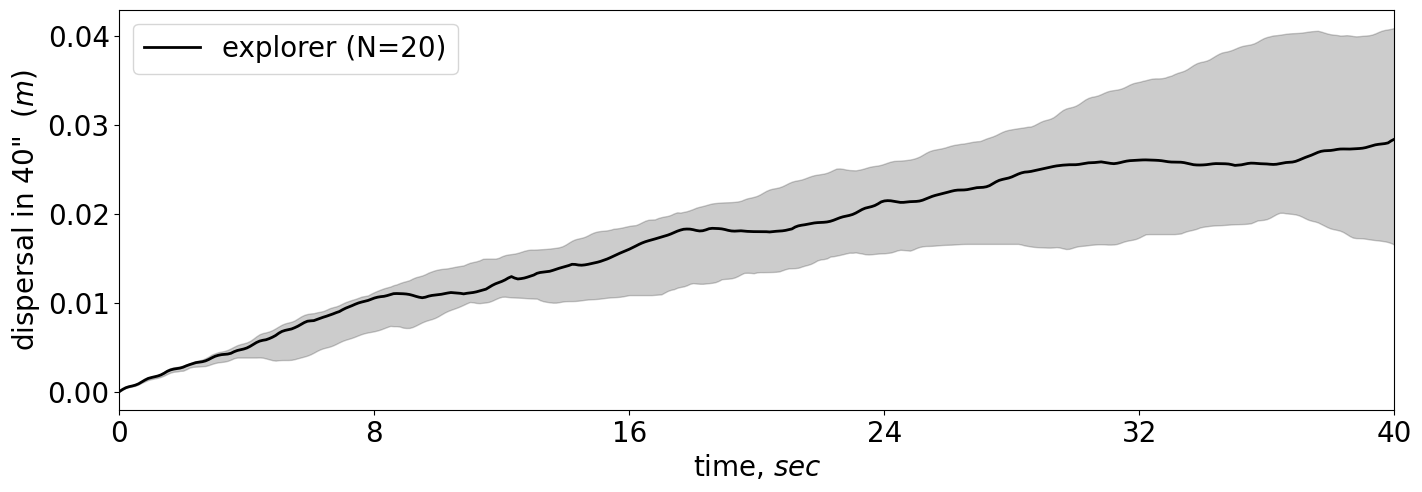

dispersal summary


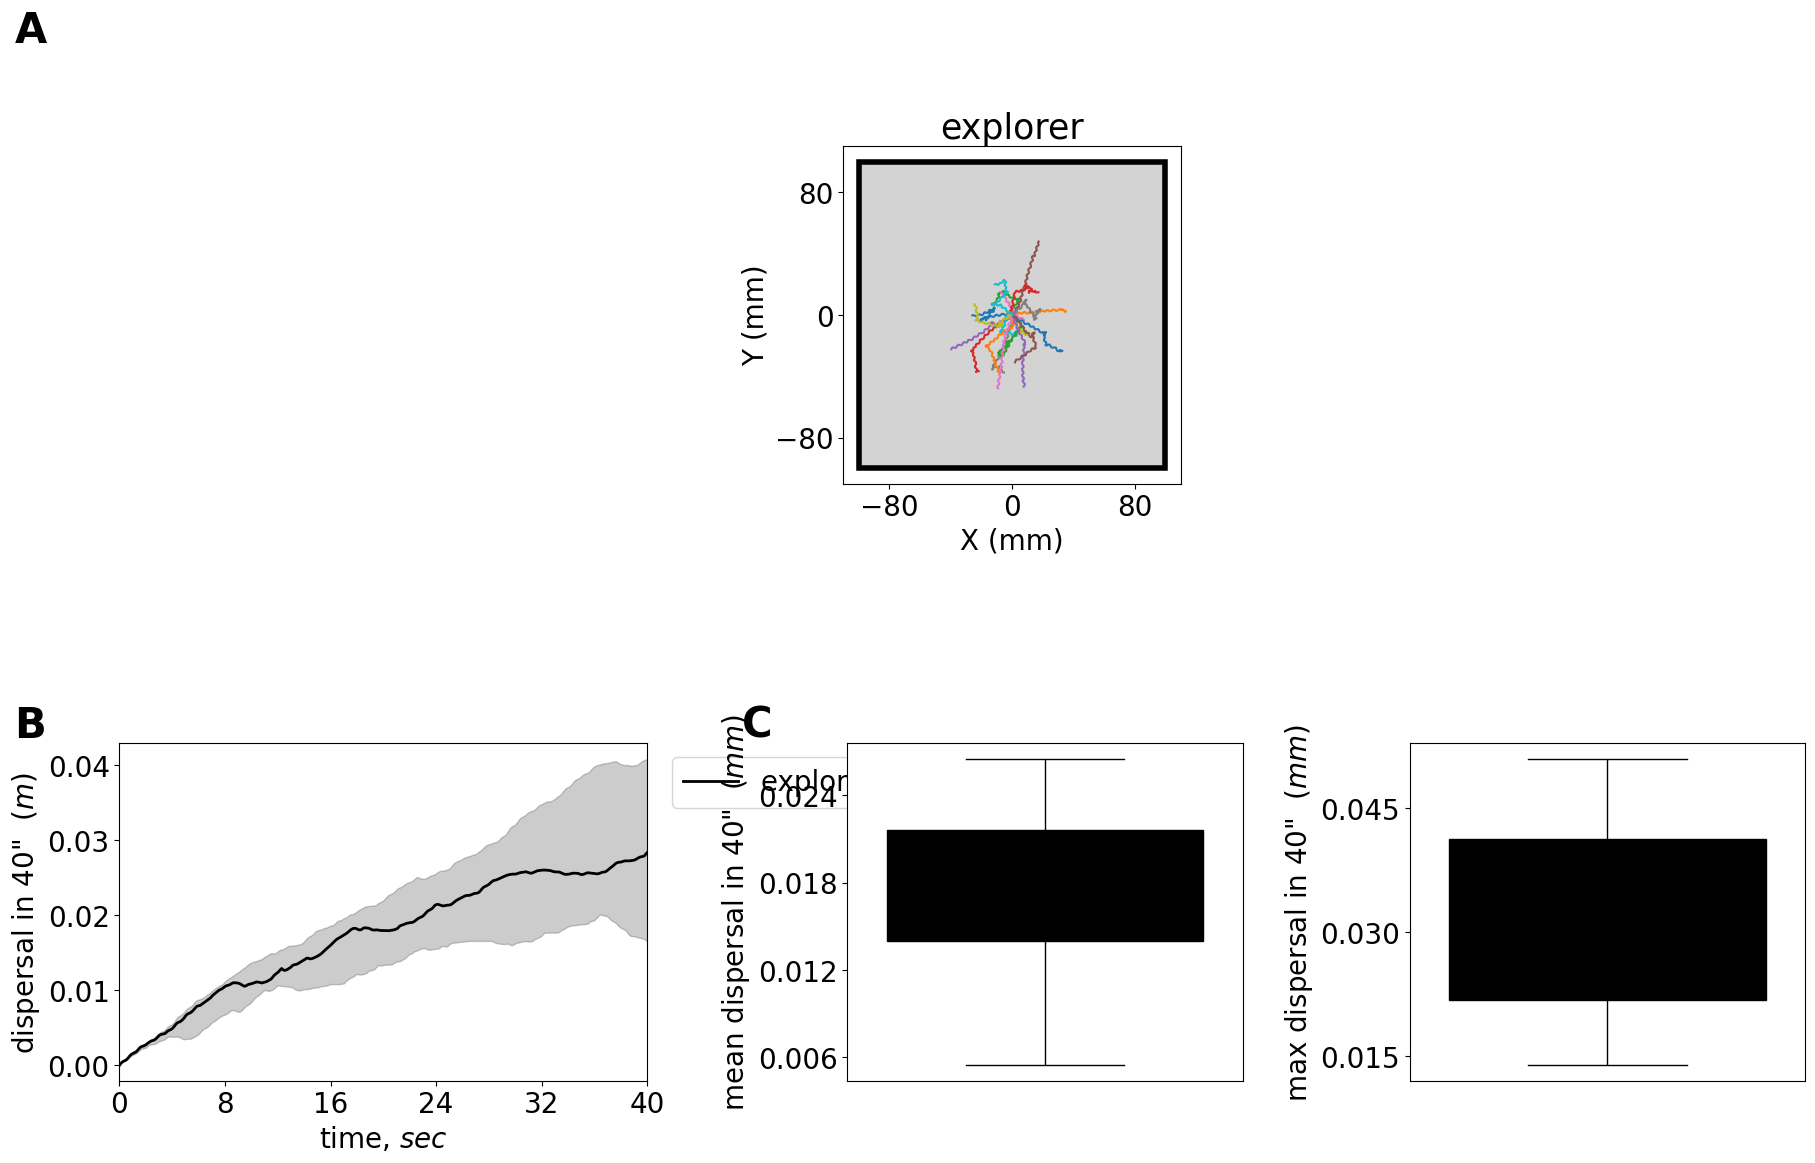

In [9]:
show("dsp")

### The paths

All tracks, and the same tracks transposed to a common origin - the picture the dispersal curve
summarizes.

trajectories


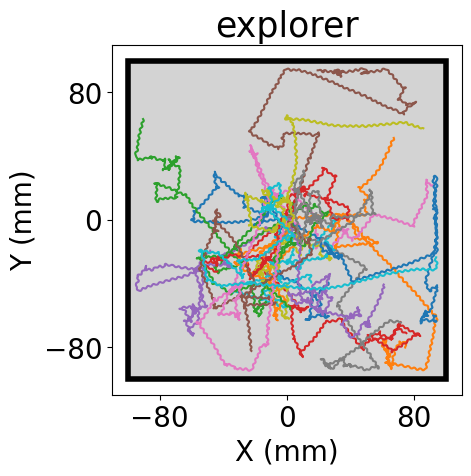

aligned2origin


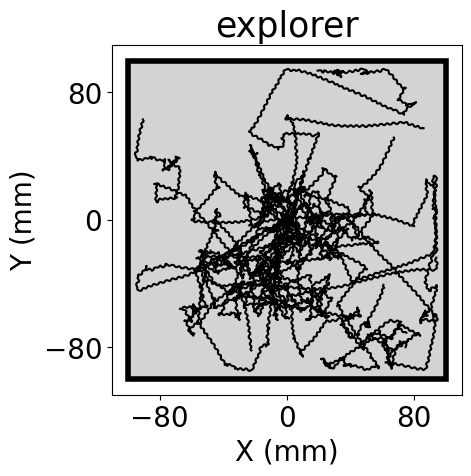

In [10]:
show("traj")

### One value per animal

Endpoint metrics, including the maximum dispersal each larva reached. These are the distributions
the paper compares between simulated and real populations.

endpoint box


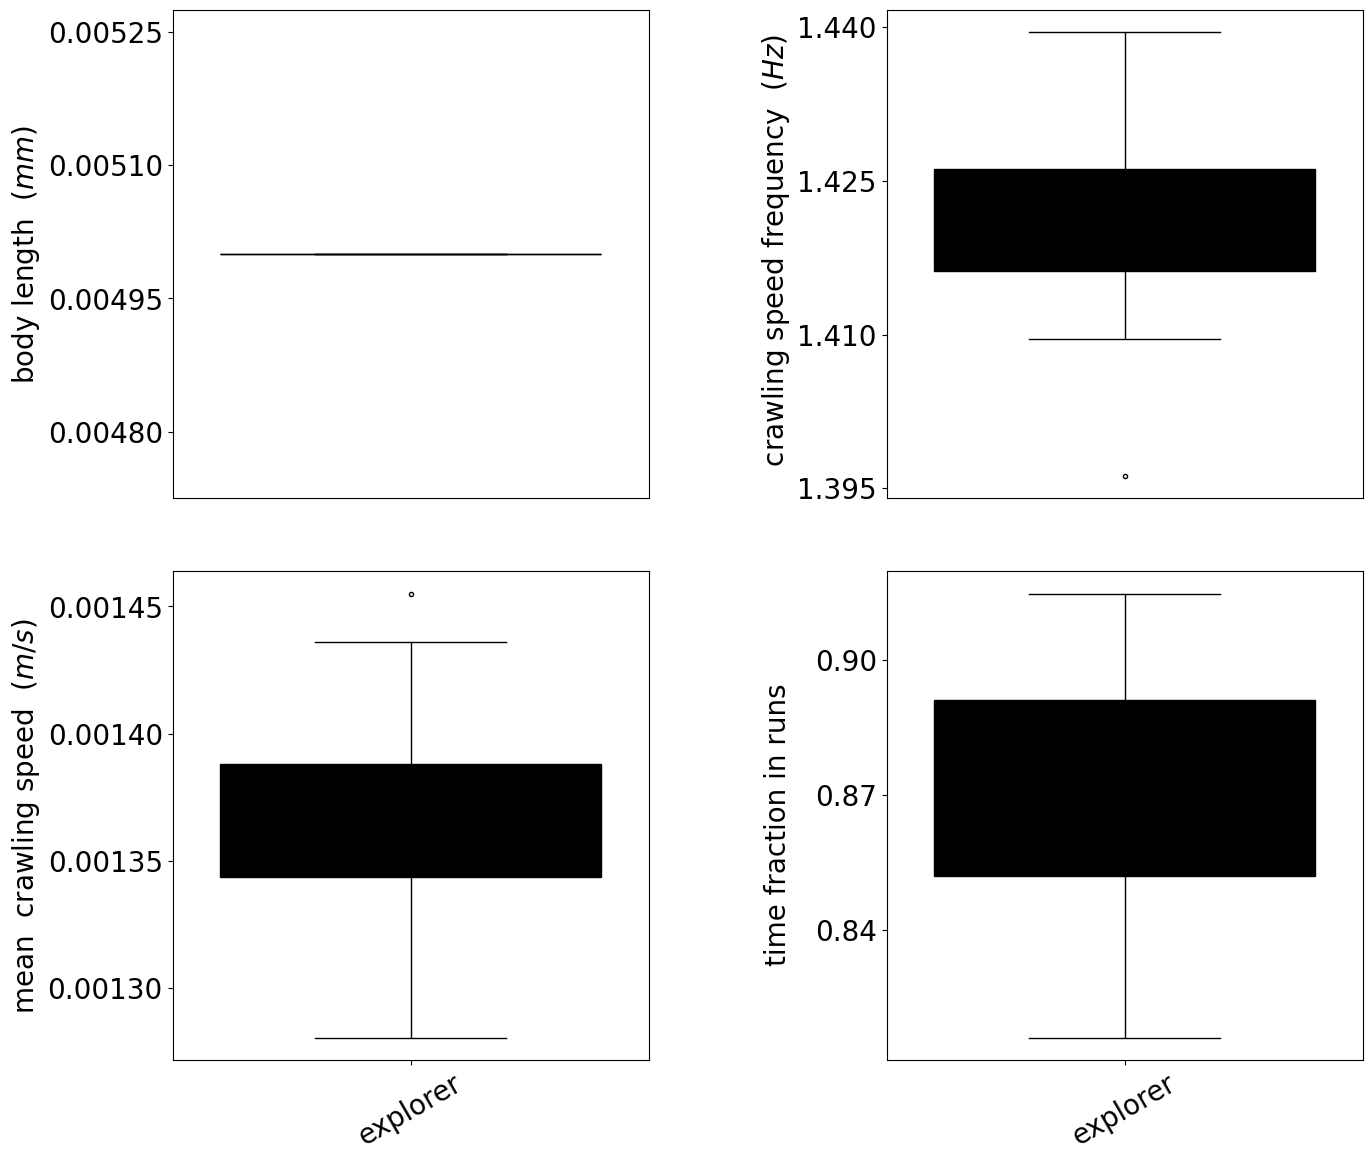

crawl pars

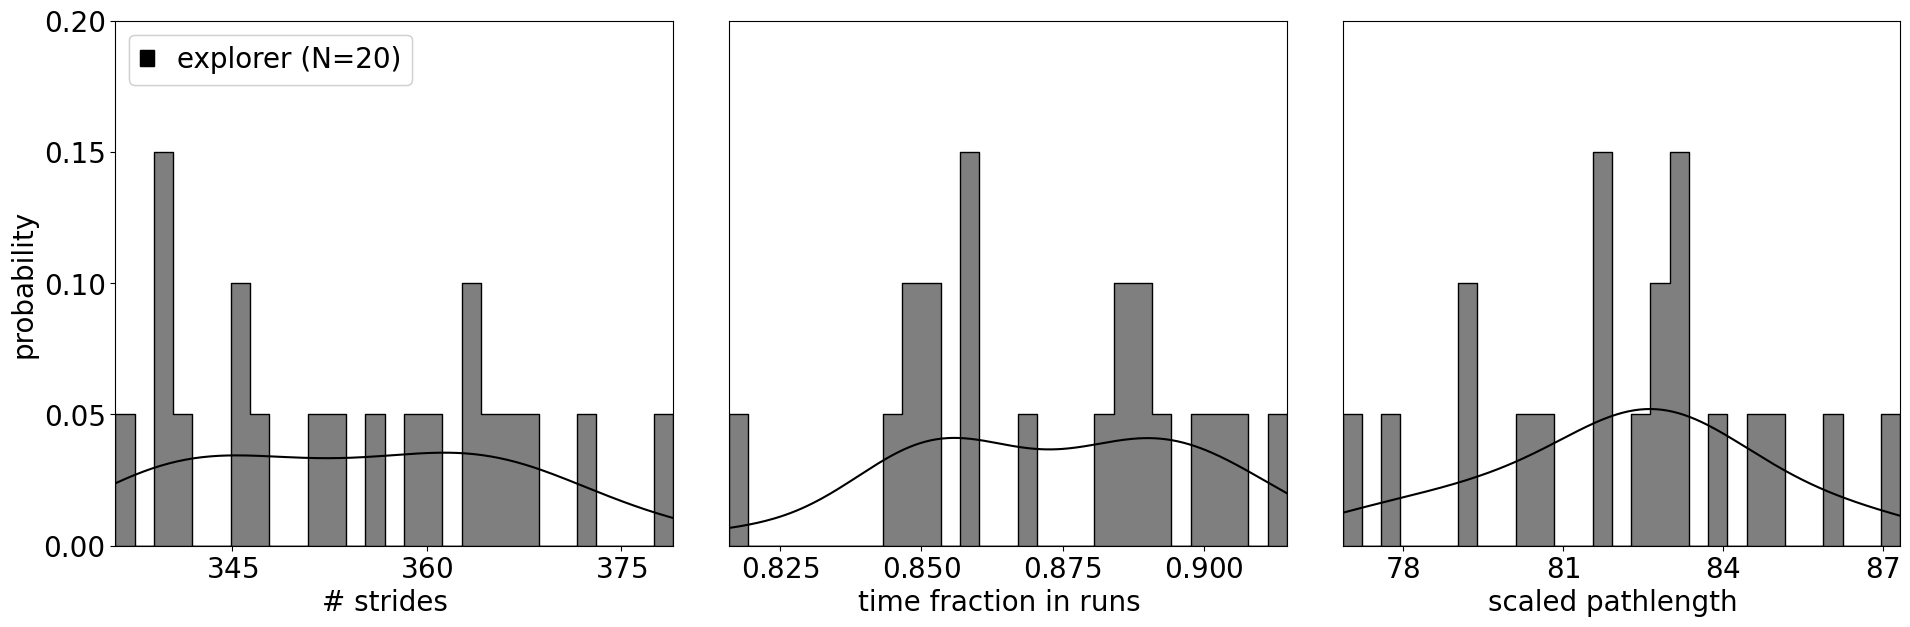

In [11]:
show("endpoint")

### Distributions and angular kinematics

distros


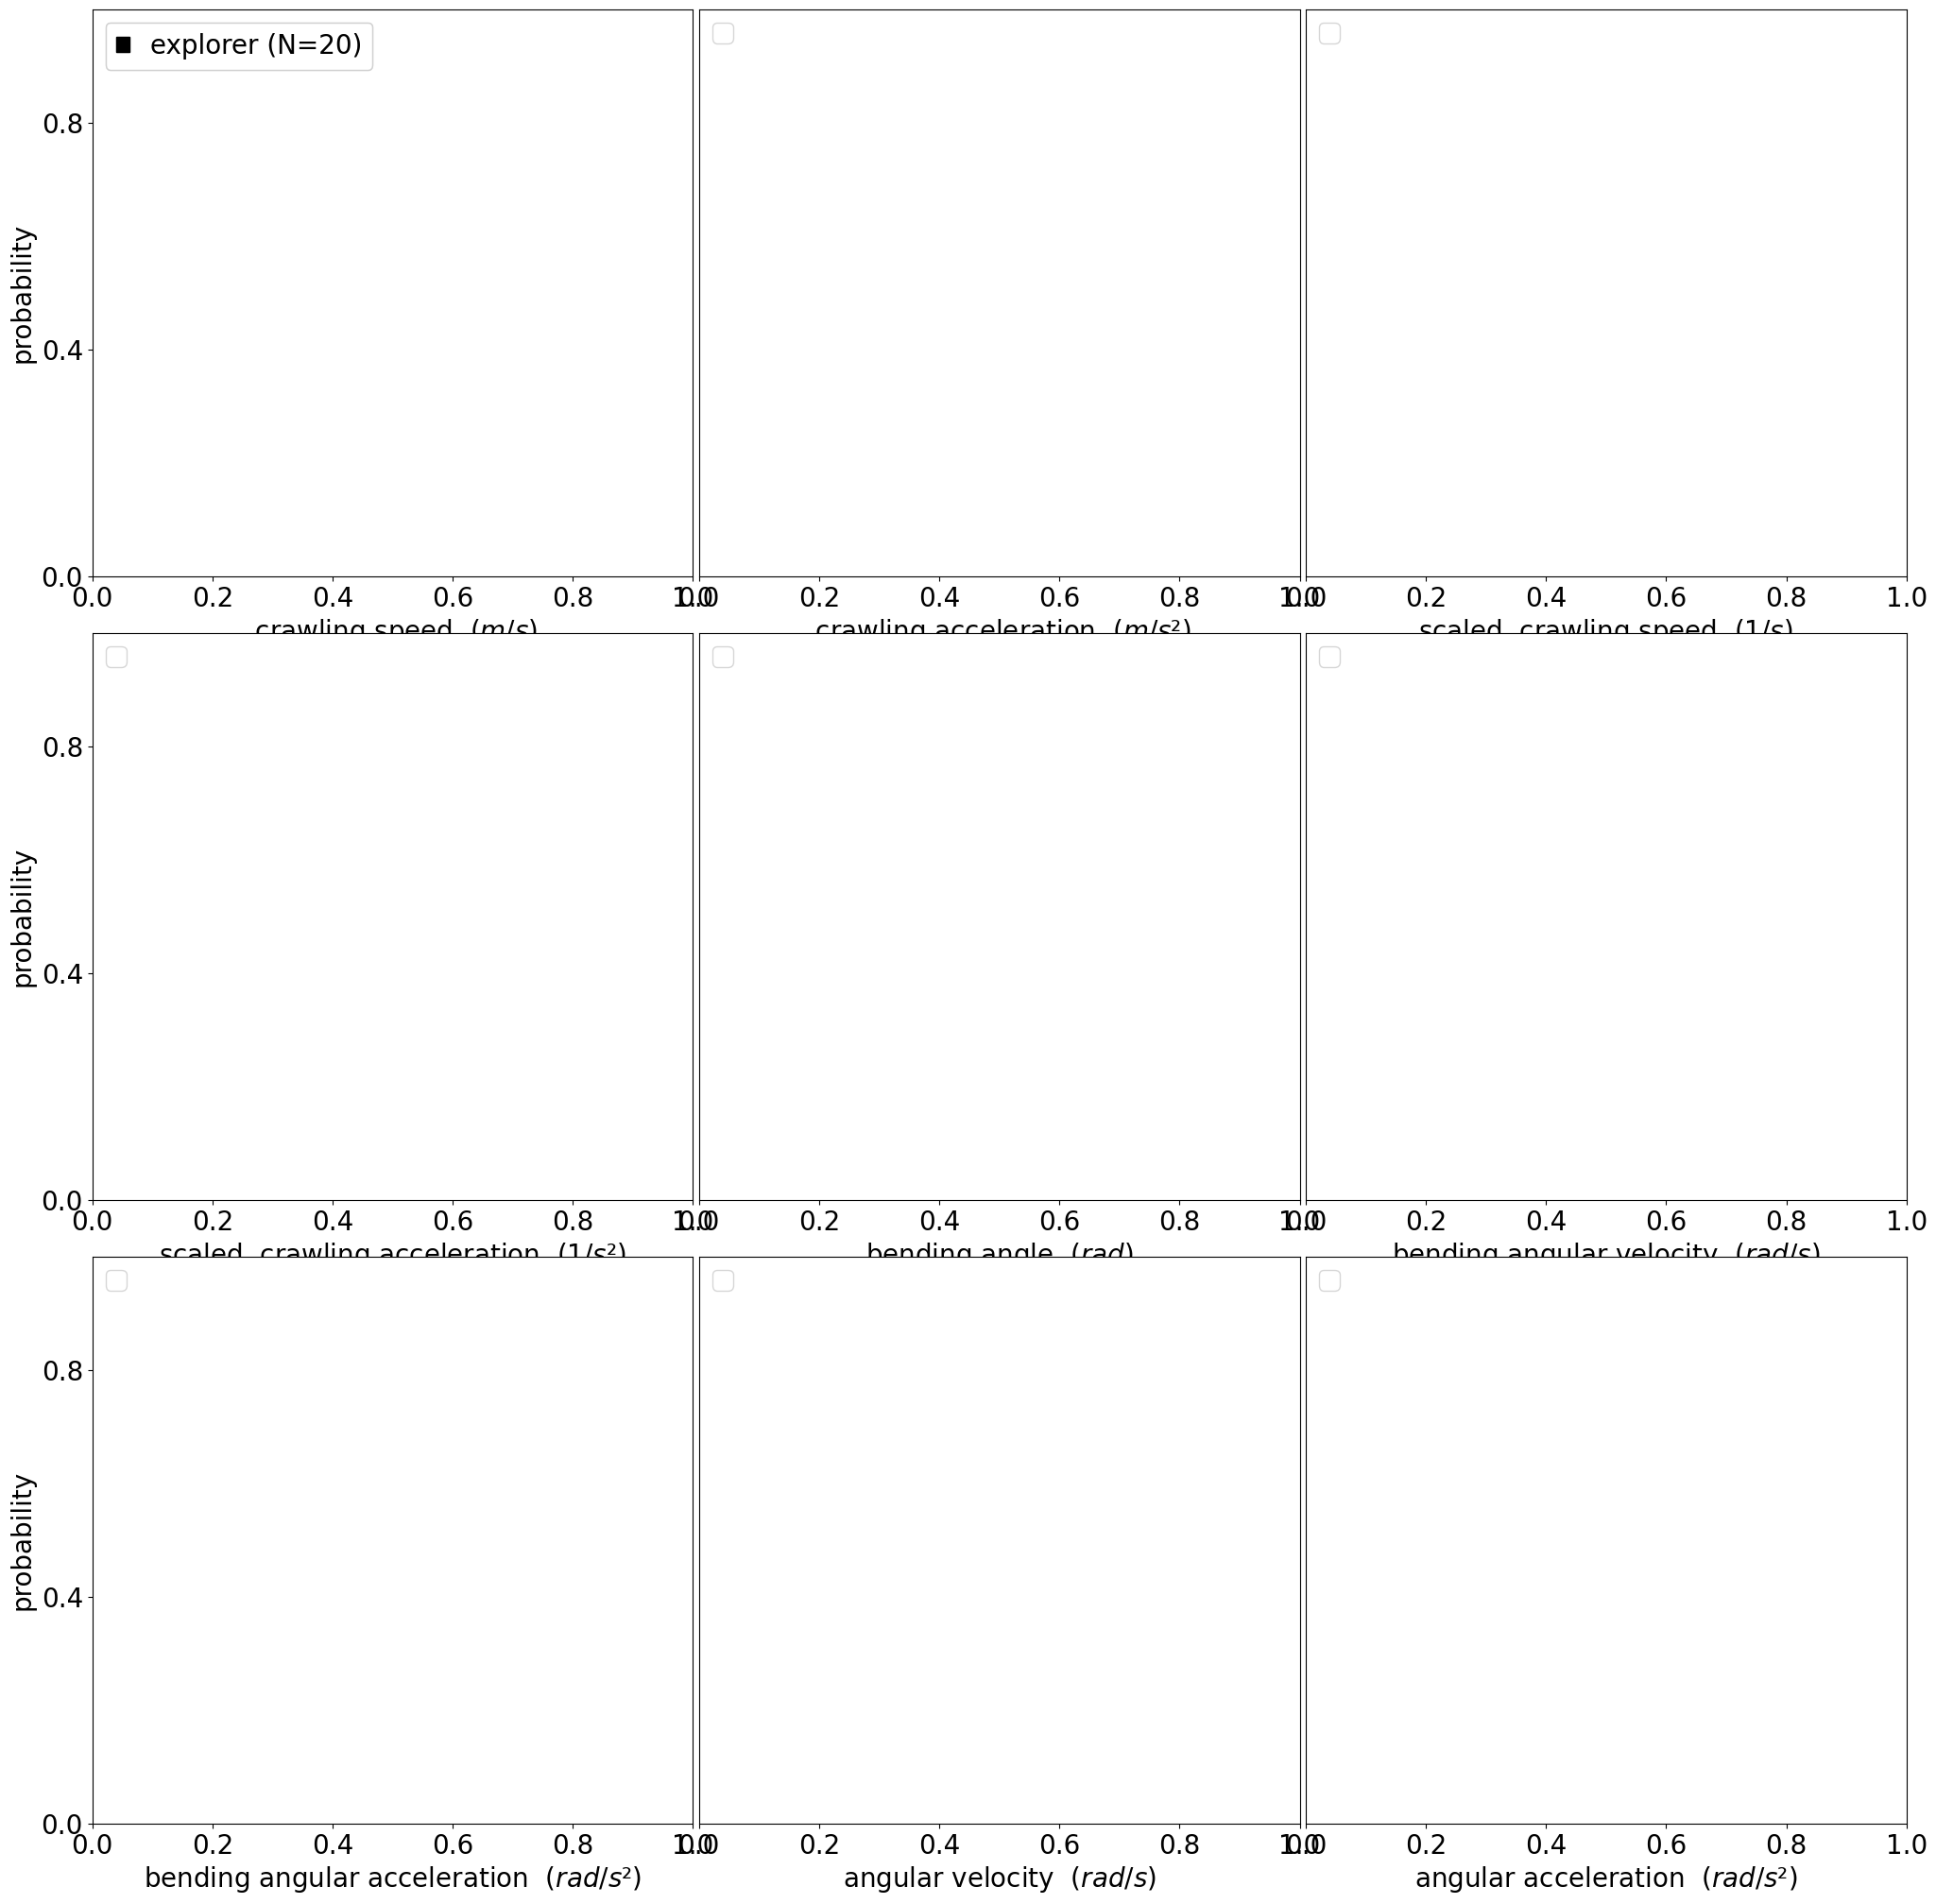

angular pars


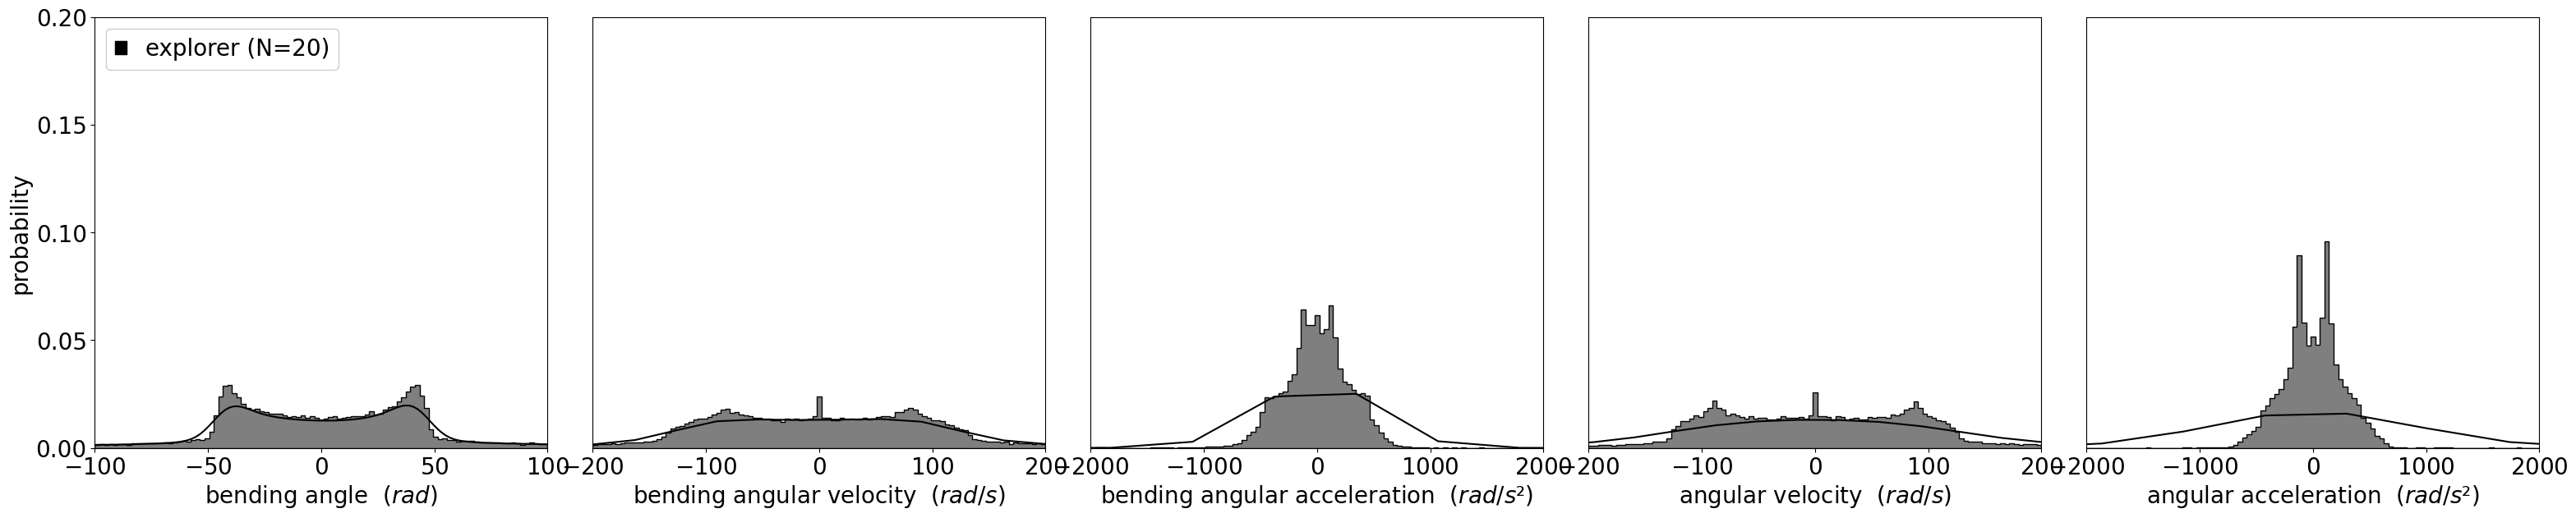

In [12]:
show("distro")

### Runs and pauses

epochs


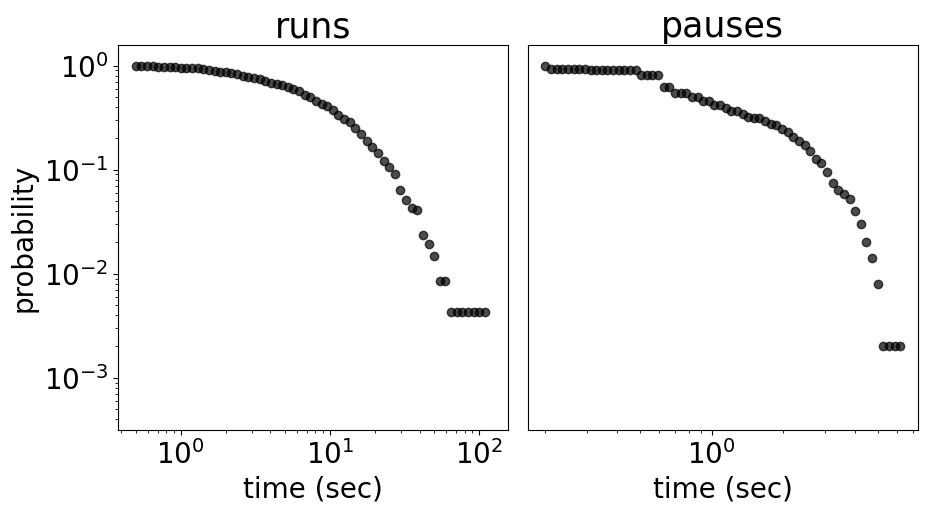

In [13]:
show("general")

### The stride cycle

stride cycle


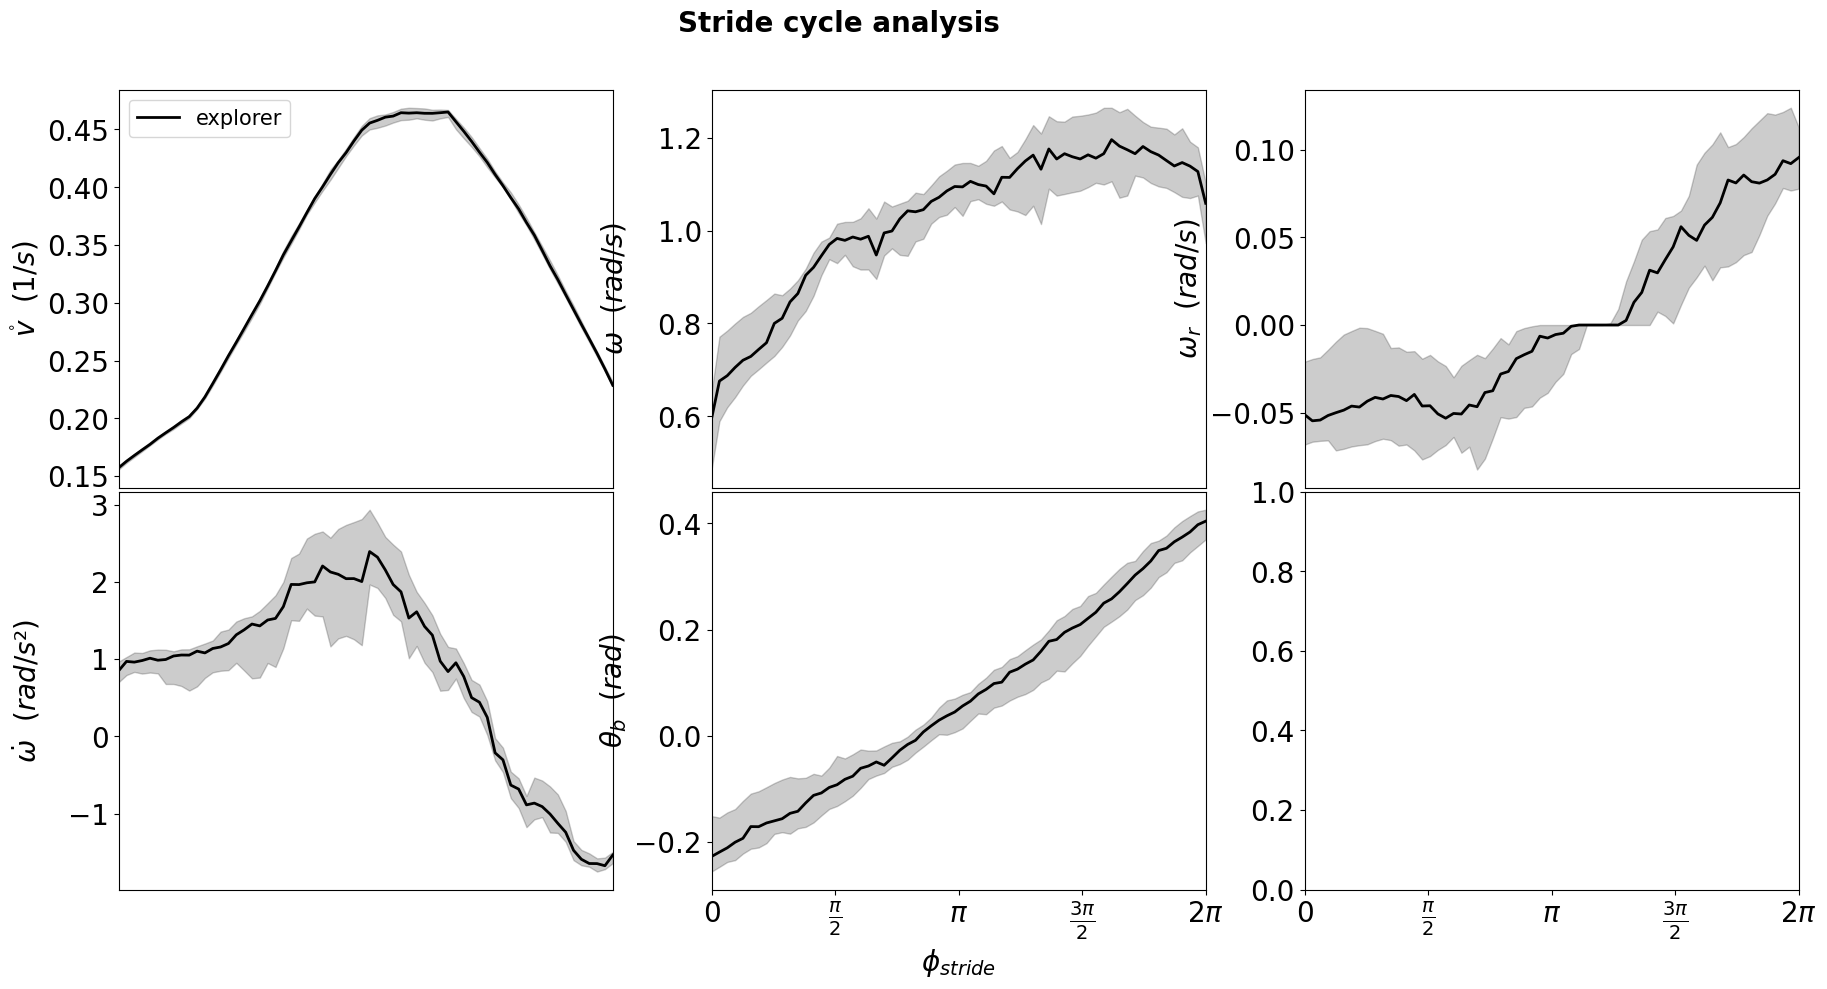

In [14]:
show("stride")

### Individual tracks, annotated

stride track


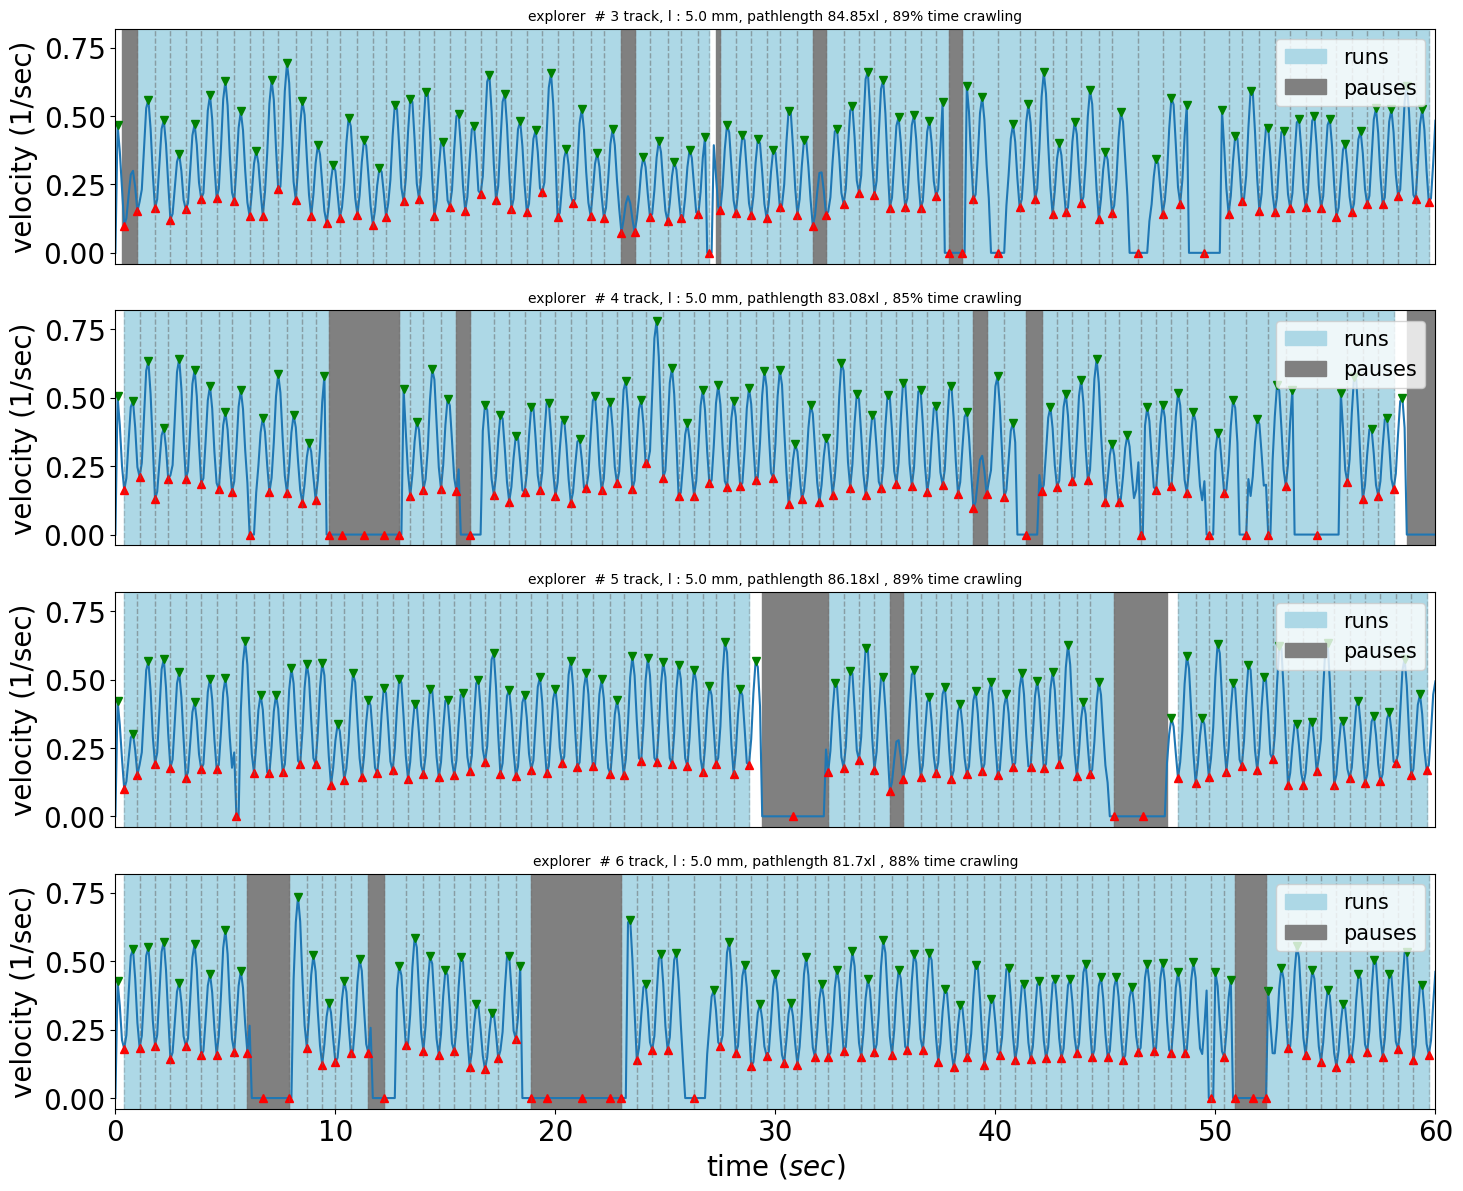

turn track


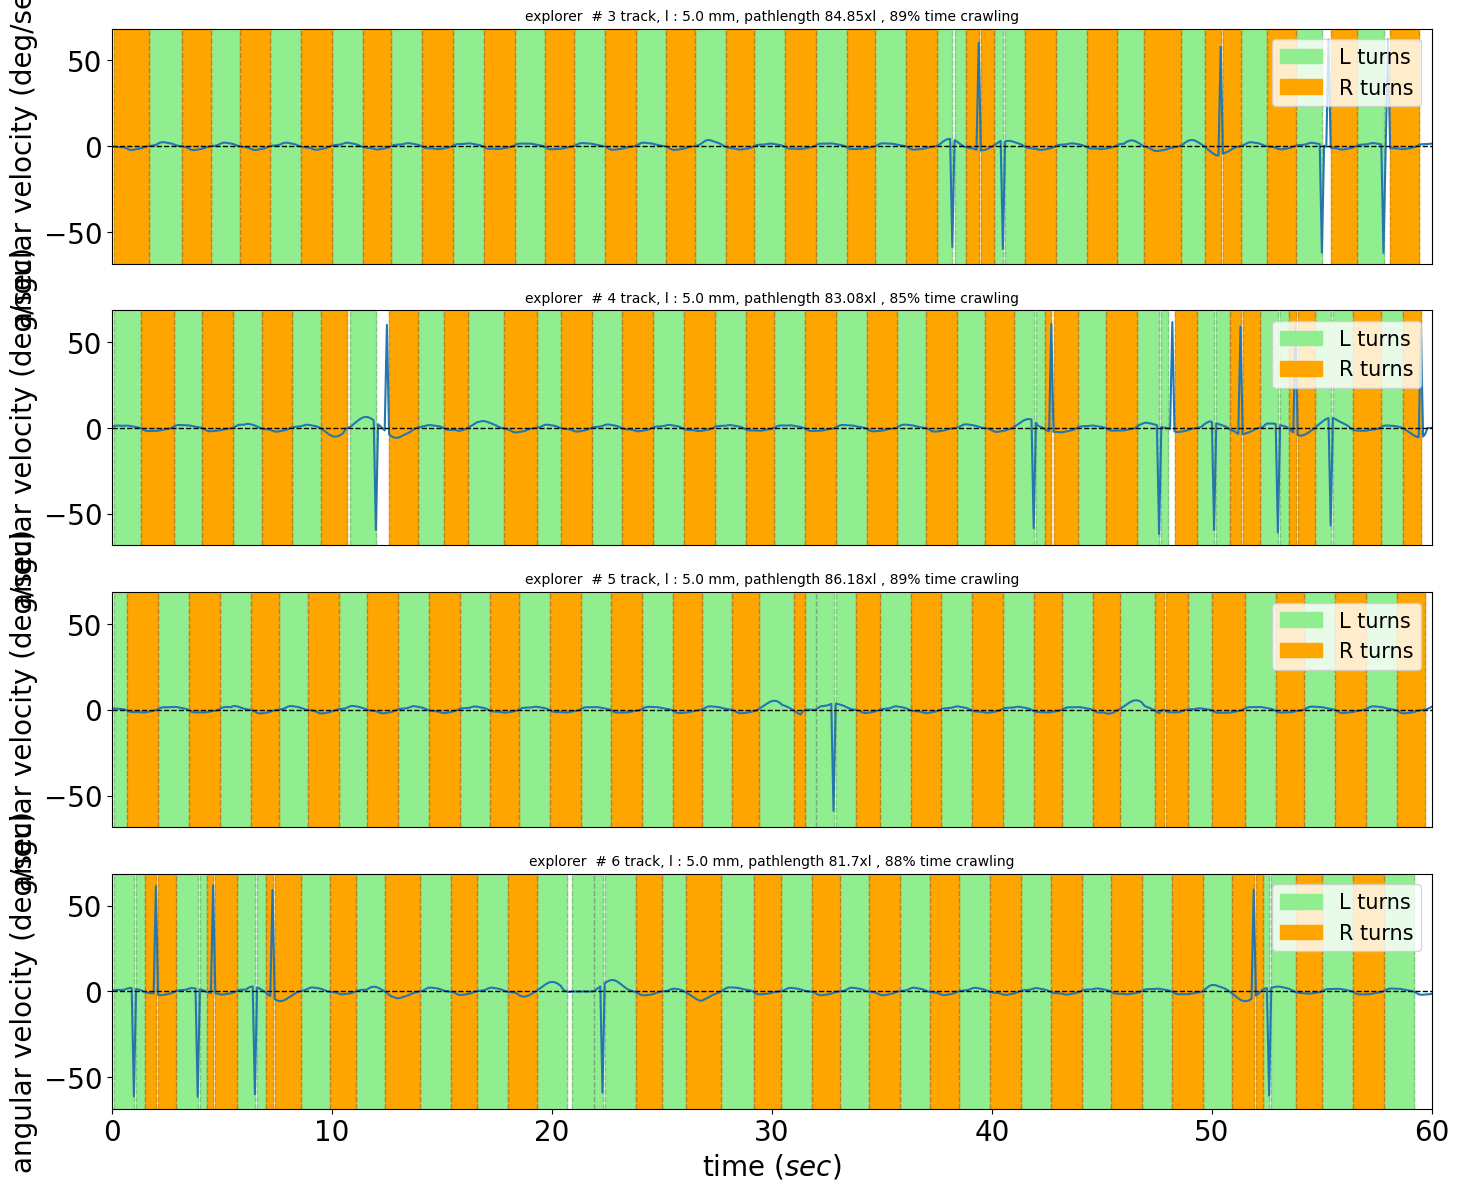

In [15]:
show("track")

## Section 4 : The real larvae

Larvaworld's default reference dataset is a recording, not a simulation. It comes from the tracking
dataset used to calibrate the model : third-instar *Drosophila* larvae (Canton S) on agarose-filled
Petri dishes of 15 cm diameter, with nothing added, video-recorded from above at 16 Hz for 3 minutes
by M. Schleyer and J. Thoener at the Leipzig Institute of Neurobiology. The full dataset holds 31
such groups of about 30 animals each; the one below is one group of it.

Because it was imported through the same pipeline that just processed the simulation, it carries the
same columns, and the plots below need nothing but both datasets in a list.

In [16]:
d_real = reg.loadRef(reg.default_refID, load=True)

for label, d in [("real larvae", d_real), ("model", d_sim)]:
    if d is None:
        continue
    c = d.config
    print(
        f"{label:12s} {d.id:12s} N={c.N:3d}  dt={c.dt:.4f} s  "
        f"duration={round(c.duration, 1)} min  arena={[round(x * 1000) for x in c.env_params.arena.dims]} mm"
    )

Loaded existing conf larvae_single
Loaded stored reference dataset : Chris.larvae_single
Loaded existing conf TopDown-2023-07-05
Loaded stored reference dataset : DeepLabCut.TopDown-2023-07-05
Loaded existing conf TopDown-2024-02-17
Loaded stored reference dataset : DeepLabCut.TopDown-2024-02-17
Loaded existing conf Fed
Loaded stored reference dataset : FeedingState.Fed
Loaded existing conf Starved
Loaded stored reference dataset : FeedingState.Starved
Loaded existing conf Sucrose
Loaded stored reference dataset : FeedingState.Sucrose
Loaded existing conf pooled
Loaded stored reference dataset : FreeExploration.pooled
Loaded existing conf single_dish
Loaded stored reference dataset : FreeExploration.single_dish
Loaded existing conf 30controls
Loaded stored reference dataset : exploration.30controls
Loaded existing conf dish01
Loaded stored reference dataset : exploration.dish01
Loaded existing conf dish02
Loaded stored reference dataset : exploration.dish02
Loaded existing conf 30contr

Loaded stored reference dataset : exploration.30controls
real larvae  30controls   N= 30  dt=0.0625 s  duration=3.0 min  arena=[150, 150] mm
model        explorer     N= 20  dt=0.1000 s  duration=5.0 min  arena=[200, 200] mm


The two are not identical recordings of the same thing, and the differences are worth stating
plainly before reading any figure :

| | real larvae | model |
|---|---|---|
| timestep | 1/16 s | 0.1 s |
| duration | 3 min | 5 min |
| arena | 150 mm circular dish | 200 mm square |
| starting positions | wherever the animals were | all at the centre |

None of that prevents the comparison, because dispersal is computed per animal from its own
starting point, in metres, against its own clock. It does mean the honest comparison window is the
**first 40 seconds** : after that, real larvae in a 15 cm dish start meeting the wall, and the curves
stop measuring the same thing.

## Section 5 : Simulated against real

Every plot below is given both datasets. Group colors and labels come from the datasets themselves,
so the two populations stay distinguishable across the whole set.

In [17]:
ds = [d for d in [d_real, d_sim] if d is not None]
plot_kws = {
    "datasets": ds,
    "labels": ["real larvae", "model"][: len(ds)],
    "save_to": plot_dir,
    "show": False,
    "subfolder": None,
}

### Dispersal over time

The measurement itself : distance from the starting point, against time. The line is the group
median and the shaded band the spread across animals, so this figure says both *how far* and *how
consistently*.

The first version is the honest one - the 0-40 s window in which both populations are still
exploring freely.

Plot dispersion_0_40.pdf saved as ./media/simulated_experiments/dispersion\dispersion_0_40.pdf


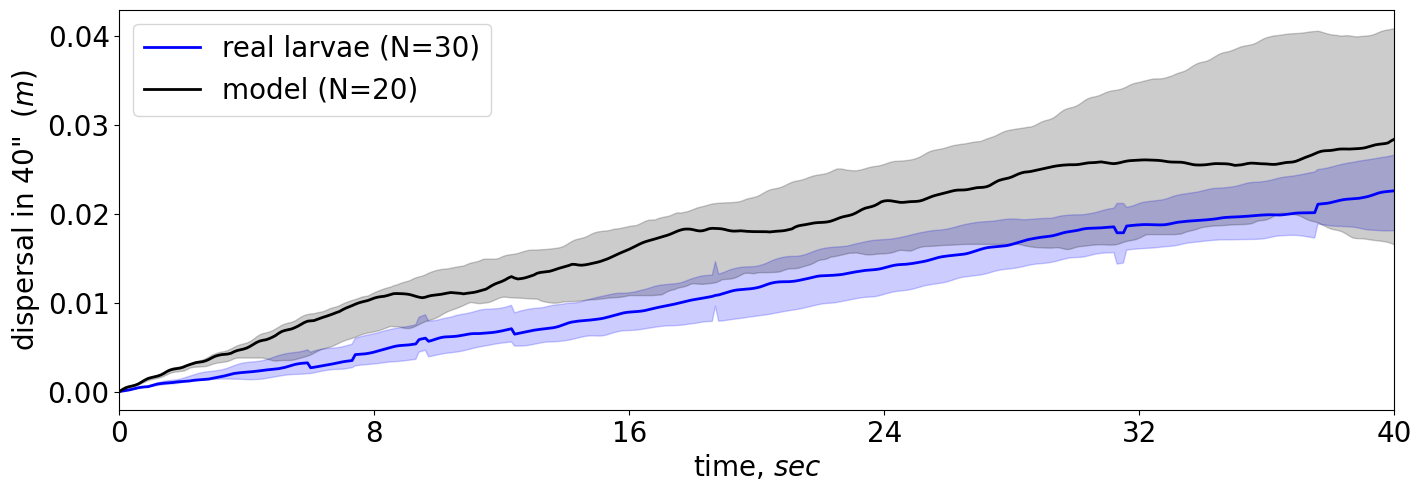

In [18]:
if len(ds) > 1:
    display(reg.graphs.run("dispersal", range=(0, 40), **plot_kws))

And the same over 0-60 s, where the real larvae begin to be constrained by the dish wall while the
model, in its larger arena, is not. The divergence at the right edge of this figure is a difference
in the *arenas*, not in the animals.

Plot dispersion_0_60.pdf saved as ./media/simulated_experiments/dispersion\dispersion_0_60.pdf


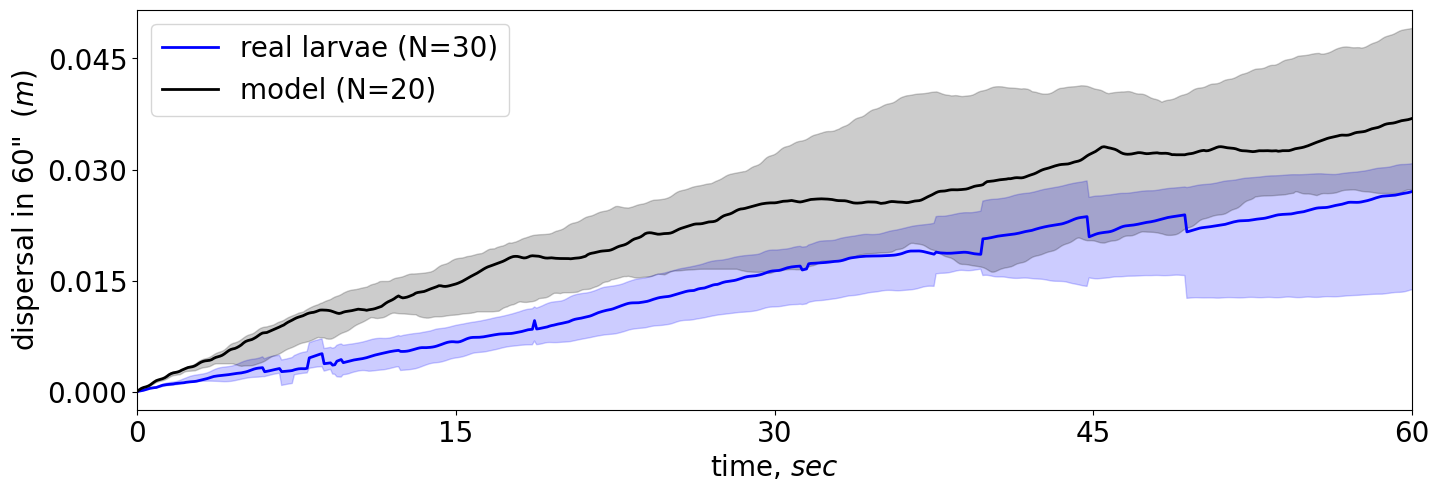

In [19]:
if len(ds) > 1:
    display(reg.graphs.run("dispersal", range=(0, 60), **plot_kws))

### The paths behind the curve

The summary version places the dispersal timecourse next to the trajectories that produced it, which
makes the link between the curve and the behavior immediate.

Plot dsp_summary_(0, 40).pdf saved as ./media/simulated_experiments/dispersion\dsp_summary_(0, 40).pdf


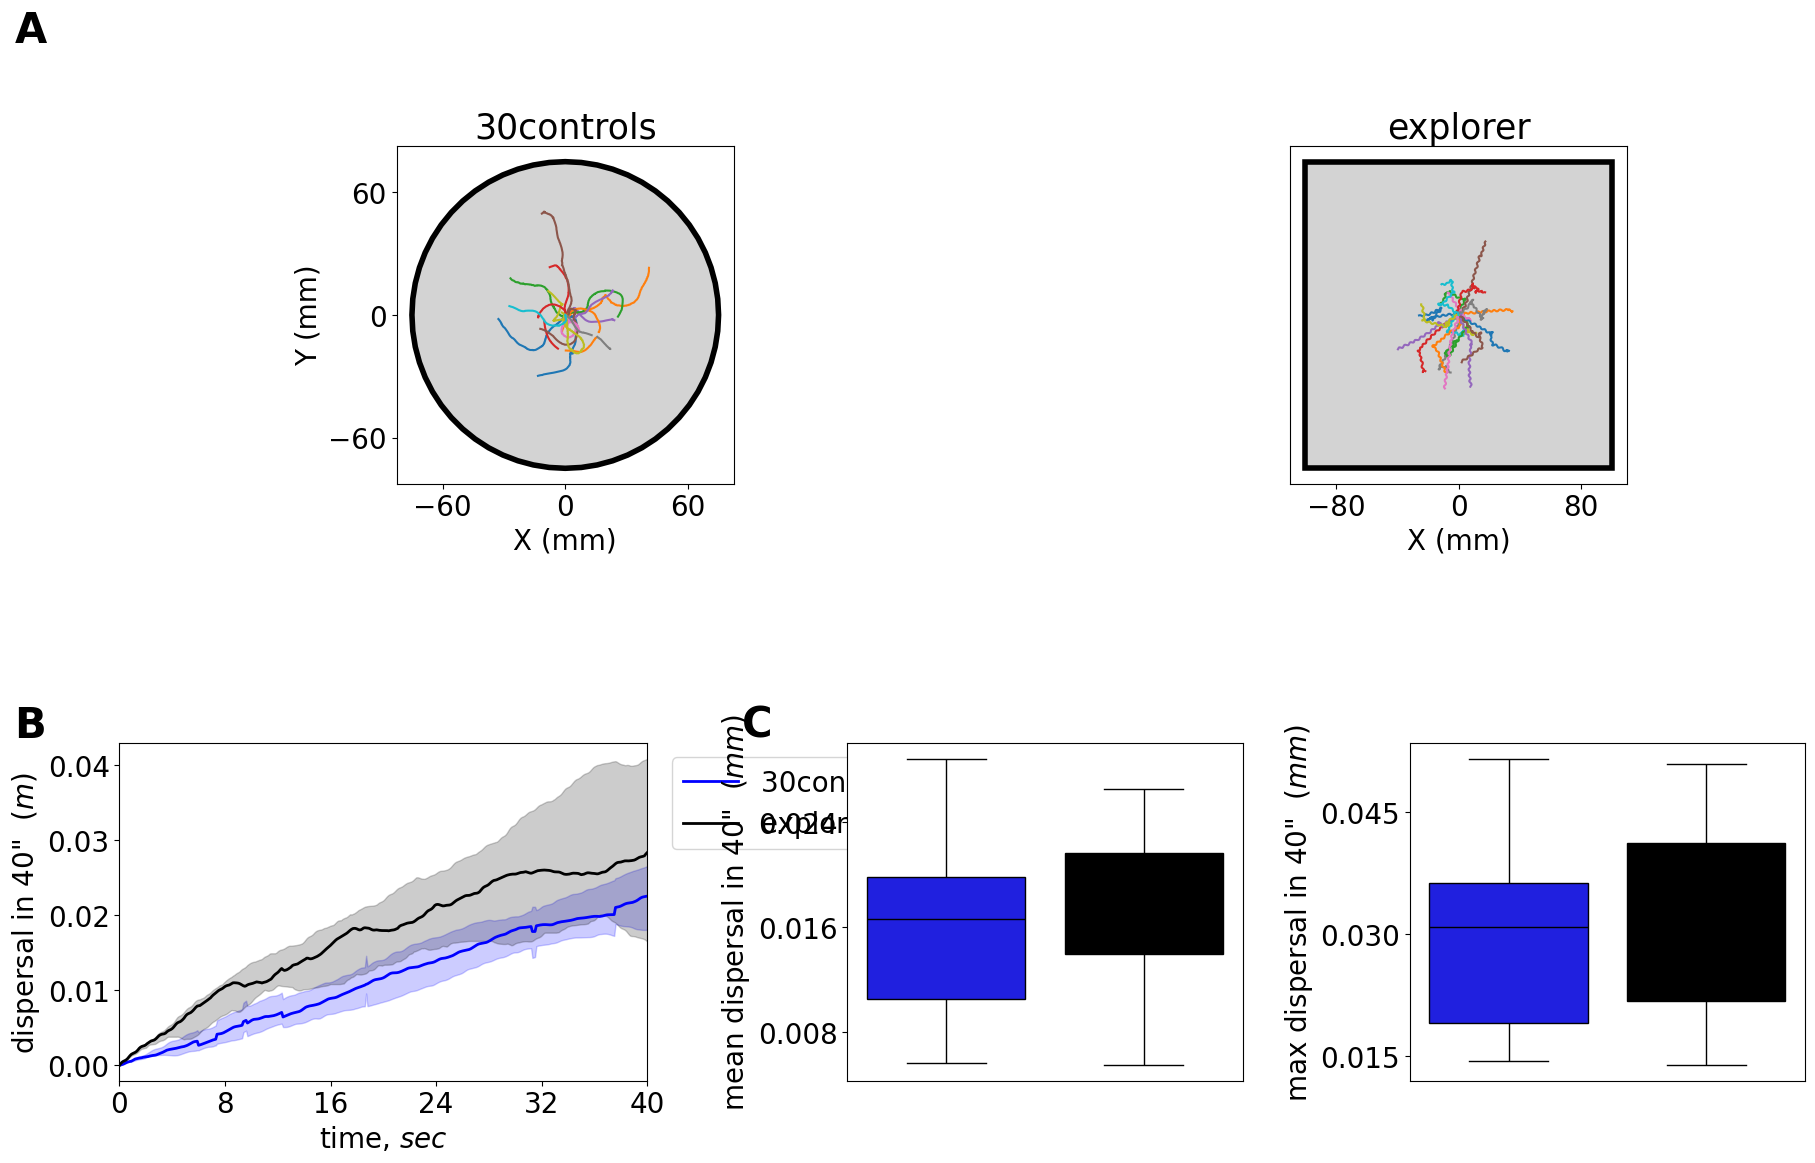

In [20]:
if len(ds) > 1:
    display(reg.graphs.run("dispersal summary", range=(0, 40), **plot_kws))

### Dispersal as a single number per animal

The timecourse collapsed to three endpoint statistics : the mean dispersal over the window, the
value reached at its end, and the maximum. One value per larva, so the boxplots show how much the
individuals of each population differ from one another - which is the comparison the paper makes in
its endpoint histograms.

Plot end_box_basic.pdf saved as ./media/simulated_experiments/dispersion\end_box_basic.pdf


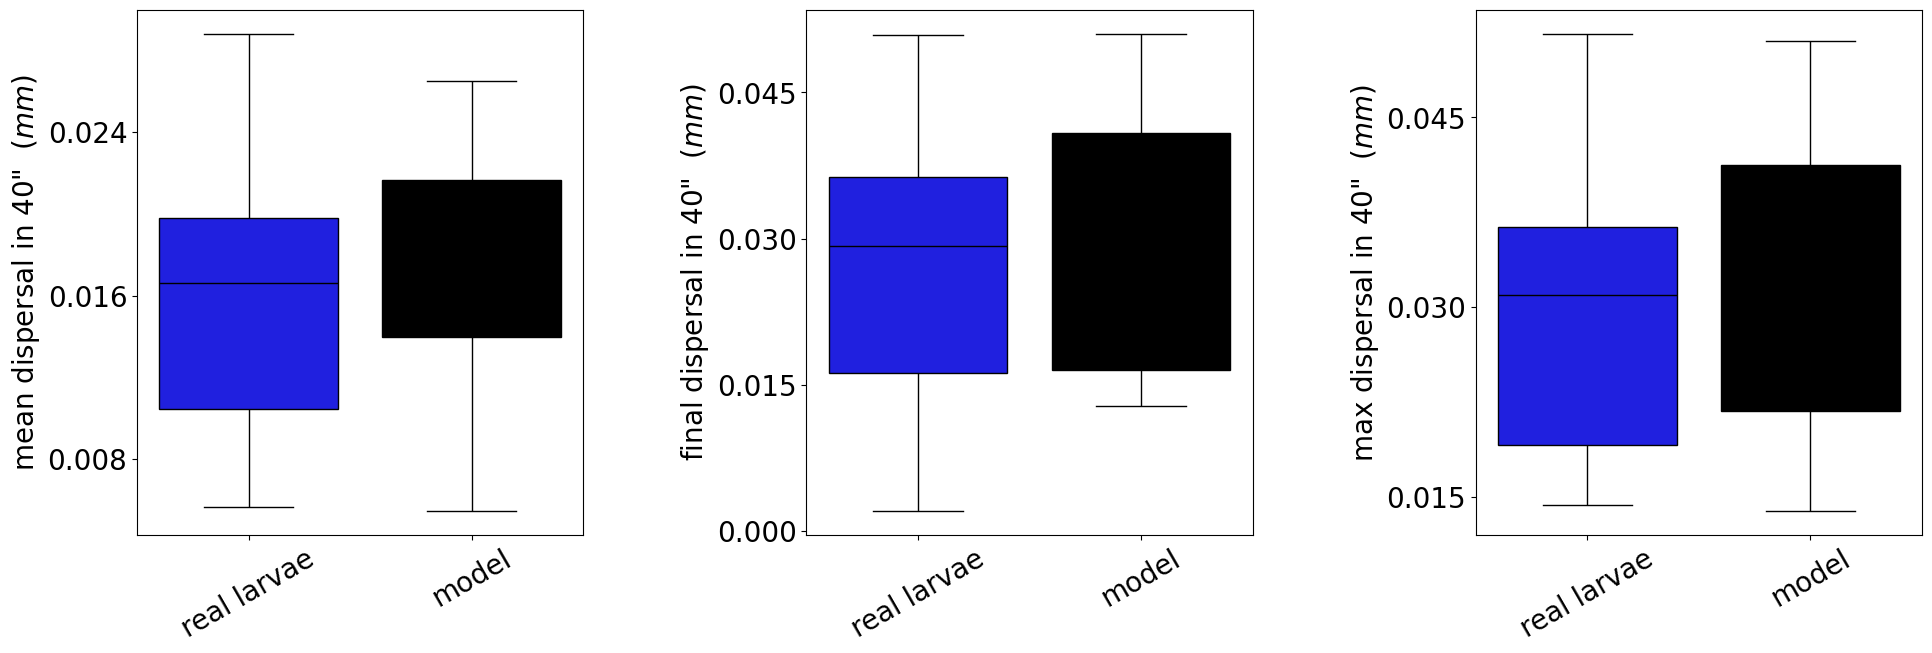

In [21]:
if len(ds) > 1:
    display(
        reg.graphs.run(
            "endpoint box",
            ks=["dsp_0_40_mu", "dsp_0_40_fin", "dsp_0_40_max"],
            **plot_kws,
        )
    )

### The tracks themselves

All trajectories transposed to a common origin and colored by population. This is the picture the
dispersal curve summarizes.

Plot comparative_trajectories_origin.pdf saved as ./media/simulated_experiments/dispersion\comparative_trajectories_origin.pdf


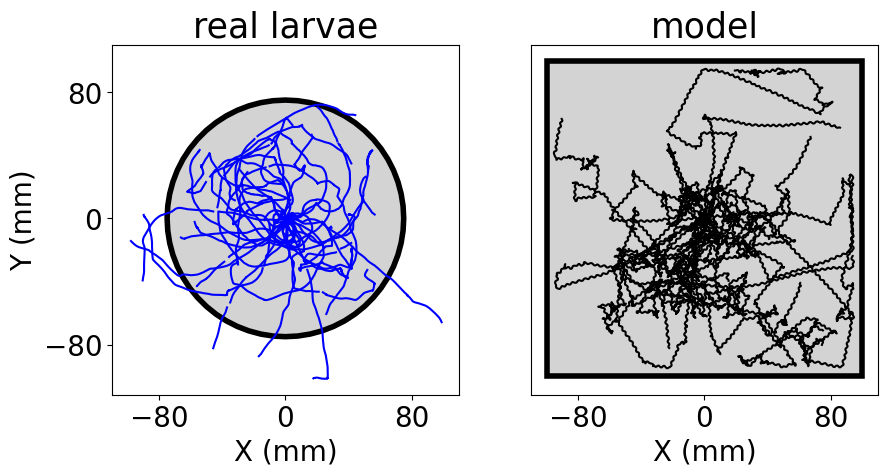

In [22]:
if len(ds) > 1:
    display(
        reg.graphs.run("trajectories", mode="origin", single_color=True, **plot_kws)
    )

## What the paper reports

This is Figure 4 of Sakagiannis et al. (2025).

**Figure 4B** is the dispersal comparison you just produced : simulated and empirical dispersal over
the first 40 seconds, with the group median and the interquartile band. The paper's version uses 200
larvae per population rather than 20, so its bands are smoother, but it is the same measurement of
the same quantity. The agreement there is the paper's main quantitative claim about the motor layer :
a model calibrated on kinematics alone reproduces a spatial statistic it was never fitted to.

**Figure 4C** makes the individual-level point, with histograms of the number of strides, the
fraction of time spent crawling, and the pathlength. The claim is not only that the average virtual
larva matches the average real one, but that the *variability between virtual individuals* matches
the variability between real animals. The endpoint boxplots above are the same idea in a different
form; the [free exploration](free_exploration.ipynb) notebook printed the underlying columns.

Two caveats the paper states and that apply here too. Dispersal is reported over the initial 40 s
because larvae reach the arena edge afterwards. And this is short-horizon exploration : the
long-horizon dispersal statistics of Sims et al. (2019) would need larger or unbounded arenas.

**A shortcut worth knowing.** `ExpRun.analyze()` performs this pairing on its own for any experiment
whose name contains `disp`, loading whichever reference dataset the larva group names as its
`sample`. Doing it by hand, as above, is clearer about where the second population comes from.

## Where to go next

- [Chemotaxis](chemotaxis.ipynb) - the same locomotion, now with something to smell.
- [Importing experimental data](../3_experimental_data/import_datasets.ipynb) - how the reference
  recording used here was made, and how to make your own.
- [Model evaluation](../5_optimization_and_evaluation/model_evaluation.ipynb) - the systematic
  version of the comparison done by eye above.
- Reference : [Reference datasets](../../data_pipeline/reference_datasets.md).

## References

> Sakagiannis PP, Jürgensen AM, Nawrot MP. 2025. *A behavioral architecture for realistic
simulations of Drosophila larva locomotion and foraging.* eLife 14:RP104262.
<https://doi.org/10.7554/eLife.104262>

> Sakagiannis PP, Rapp H, Jovanic T, Nawrot MP. 2025. *Larvaworld: a behavioral simulation and
analysis platform for Drosophila larva.* bioRxiv.
<https://doi.org/10.1101/2025.06.15.659765>

> Sims DW, Humphries NE, Hu N, Medan V, Berni J. 2019. *Optimal searching behaviour generated
intrinsically by the central pattern generator for locomotion.* eLife 8:e50316.
<https://doi.org/10.7554/eLife.50316>